In [23]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

In [19]:
import os
import warnings

warnings.filterwarnings('ignore')

In [5]:
df=pd.read_csv('premier-player-23-24.csv')
df.head(5)

,Player,Nation,Pos,Age,MP,Starts,Min,90s,Gls,Ast,...,Ast_90,G+A_90,G-PK_90,G+A-PK_90,xG_90,xAG_90,xG+xAG_90,npxG_90,npxG+xAG_90,Team
0,Rodri,es ESP,MF,27.0,34,34,2931.0,32.6,8.0,9.0,...,0.28,0.52,0.25,0.52,0.12,0.12,0.24,0.12,0.24,Manchester City
1,Phil Foden,eng ENG,"FW,MF",23.0,35,33,2857.0,31.7,19.0,8.0,...,0.25,0.85,0.60,0.85,0.33,0.26,0.59,0.33,0.59,Manchester City
2,Ederson,br BRA,GK,29.0,33,33,2785.0,30.9,0.0,0.0,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Manchester City
3,Julián Álvarez,ar ARG,"MF,FW",23.0,36,31,2647.0,29.4,11.0,8.0,...,0.27,0.65,0.31,0.58,0.44,0.22,0.66,0.39,0.61,Manchester City
4,Kyle Walker,eng ENG,DF,33.0,32,30,2767.0,30.7,0.0,4.0,...,0.13,0.13,0.00,0.13,0.01,0.09,0.10,0.01,0.10,Manchester City


In [6]:
print(f"Total players before filtering: {len(df)}")

Total players before filtering: 580


In [7]:
min_minutes_threshold = 500
df_filtered = df[df['Min'] >= min_minutes_threshold]
df_filtered = df_filtered[df_filtered['Pos'] != 'GK']
df_filtered = df_filtered.reset_index(drop=True)

In [8]:
print(f"Total outfield players after filtering (> {min_minutes_threshold} mins): {len(df_filtered)}")

Total outfield players after filtering (> 500 mins): 366


# Part 2

In [11]:
df_filtered['PrgC_90'] = df_filtered['PrgC'] / df_filtered['90s']
df_filtered['PrgP_90'] = df_filtered['PrgP'] / df_filtered['90s']
df_filtered['PrgR_90'] = df_filtered['PrgR'] / df_filtered['90s']

In [12]:
features = [
    'Gls_90', 'Ast_90',       # Actual output 
    'xG_90', 'xAG_90',        # Expected output (often better for clustering underlying performance)
    'PrgC_90', 'PrgP_90', 'PrgR_90' # Ball progression and positioning
]

In [13]:
df_features = df_filtered[features].copy()

In [14]:
#scaling the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_features)

In [15]:
df_scaled = pd.DataFrame(scaled_data, columns=features)
print("Data successfully scaled!")
df_scaled.head()

Data successfully scaled!


,Gls_90,Ast_90,xG_90,xAG_90,PrgC_90,PrgP_90,PrgR_90
0,0.570390,1.465593,-0.205647,0.086659,0.271384,4.060564,-0.675705
1,2.552672,1.209429,1.099559,1.547312,0.664574,0.777365,1.398102
2,1.250029,1.380205,1.783238,1.129982,0.170606,-0.168657,0.677206
3,-0.845526,0.184774,-0.889327,-0.226339,0.323030,0.679576,0.518638
4,0.343843,1.721757,-0.143495,1.651644,1.944619,1.245628,1.582677


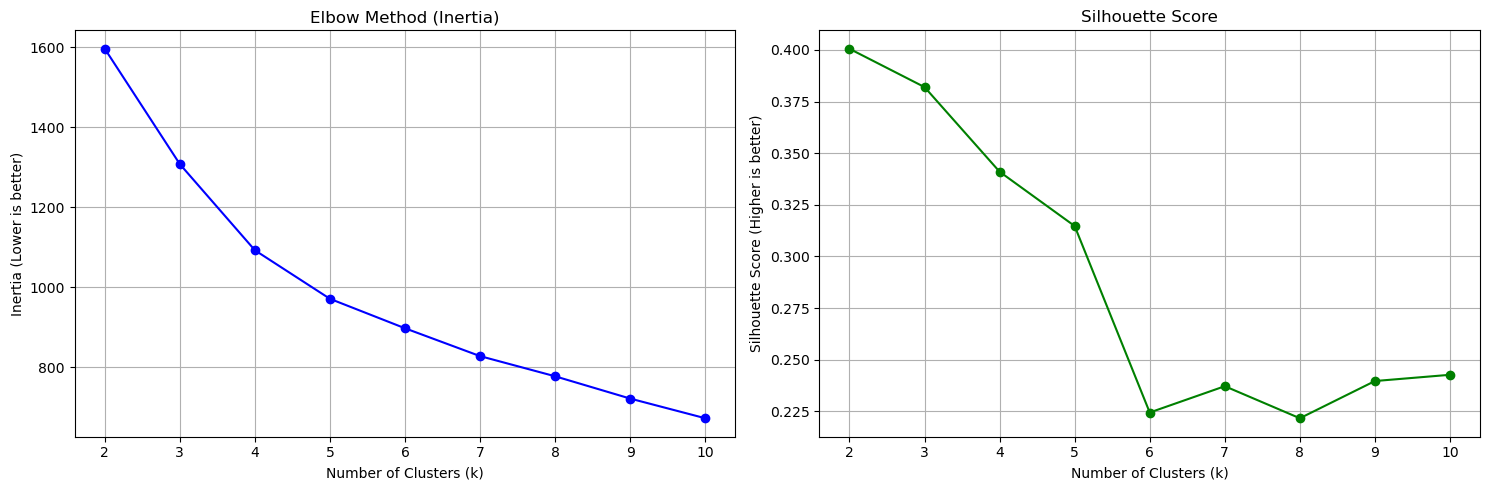

In [20]:
k_range = range(2, 11)
inertia = []
silhouette_scores = []
for k in k_range:
    # 1. Initialize K-Means model (random_state ensures we get identical results every time)
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    
    # 2. Fit the model to our scaled data
    kmeans.fit(df_scaled)
    
    # 3. Save the inertia (for the elbow curve)
    inertia.append(kmeans.inertia_)
    
    # 4. Save the silhouette score
    score = silhouette_score(df_scaled, kmeans.labels_)
    silhouette_scores.append(score)
# Plotting the results!
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
# Plot 1: Elbow Method (Inertia)
ax1.plot(k_range, inertia, marker='o', linestyle='-', color='b')
ax1.set_title('Elbow Method (Inertia)')
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia (Lower is better)')
ax1.grid(True)
# Plot 2: Silhouette Score
ax2.plot(k_range, silhouette_scores, marker='o', linestyle='-', color='g')
ax2.set_title('Silhouette Score')
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score (Higher is better)')
ax2.grid(True)
plt.tight_layout()
plt.show()

In [21]:
# Escolhe o número de clusters baseado nos gráficos do passo anterior
k_final = 6
# 1. Criar o modelo final
kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
# 2. Treinar o modelo e prever a que grupo cada jogador pertence
cluster_labels = kmeans_final.fit_predict(df_scaled)
# 3. Adicionar as labels (0 a 5) ao nosso dataframe original filtrado
df_filtered['Cluster'] = cluster_labels
# Vamos ver quantos jogadores ficaram em cada grupo!
print(df_filtered['Cluster'].value_counts())

Cluster
4    119
0     97
2     57
3     41
5     27
1     25
Name: count, dtype: int64


In [22]:
grupo_0 = df_filtered[df_filtered['Cluster'] == 0]
# Mostrar o Nome, Equipa, Posição original e as suas estatísticas
display_columns = ['Player', 'Team', 'Pos', 'PrgC_90', 'PrgP_90', 'xG_90', 'xAG_90']
print("JOGADORES NO CLUSTER 0:")
grupo_0[display_columns].head(15)

JOGADORES NO CLUSTER 0:


,Player,Team,Pos,PrgC_90,PrgP_90,xG_90,xAG_90
3,Kyle Walker,Manchester City,DF,2.410423,5.114007,0.01,0.09
6,Rúben Dias,Manchester City,DF,1.197183,6.091549,0.05,0.01
7,Manuel Akanji,Manchester City,"DF,MF",1.648746,5.304659,0.07,0.02
8,Joško Gvardiol,Manchester City,DF,2.432432,5.250965,0.12,0.06
9,Nathan Aké,Manchester City,DF,1.057269,5.110132,0.11,0.05
11,Mateo Kovačić,Manchester City,MF,2.151163,5.813953,0.07,0.09
13,John Stones,Manchester City,"DF,MF",1.355932,4.830508,0.09,0.02
15,Rico Lewis,Manchester City,"DF,MF",2.333333,3.666667,0.07,0.12
17,Virgil van Dijk,Liverpool,DF,0.906516,5.665722,0.08,0.04
24,Wataru Endo,Liverpool,MF,0.523560,5.287958,0.03,0.09


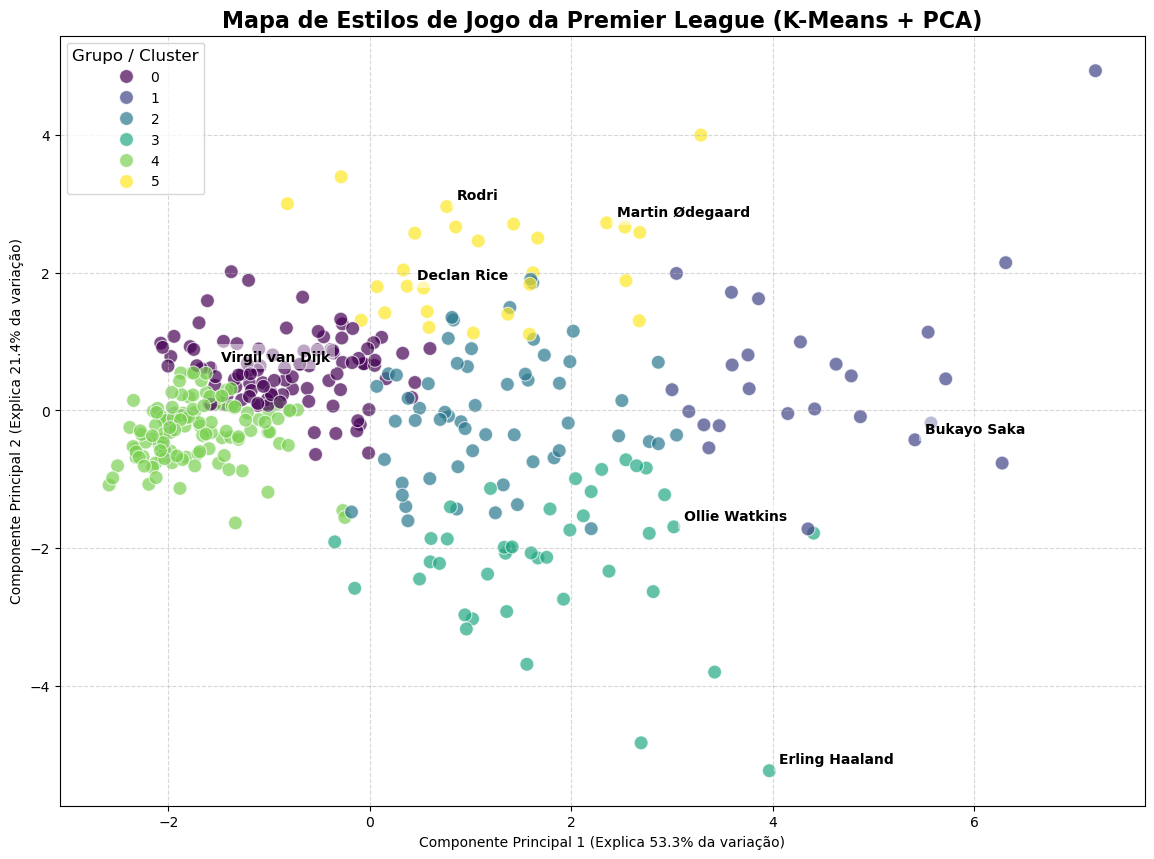

In [24]:
# 1. Instanciar o PCA para reduzir as nossas 6 variáveis para apenas 2 componentes principais (eixo X e eixo Y)
pca = PCA(n_components=2)

# 2. Ensinar ao PCA os nossos dados escalados e transformá-los logo de seguida
componentes_principais = pca.fit_transform(df_scaled)

# 3. Adicionar estas 2 novas "coordenadas matemáticas" ao nosso dataframe principal
df_filtered['PCA1'] = componentes_principais[:, 0]
df_filtered['PCA2'] = componentes_principais[:, 1]

# 4. Desenhar o gráfico!
plt.figure(figsize=(14, 10))

# O seaborn é espetacular para isto porque pinta automaticamente as cores com o parâmetro "hue"
sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='Cluster', 
    data=df_filtered, 
    palette='viridis', # 'viridis' ou 'tab10' são ótimas paletas
    s=100,             # Tamanho da bolinha
    alpha=0.7          # Transparência para ver bolinhas sobrepostas
)

# 5. [Bónus] Vamos colocar o nome de alguns jogadores famosos no gráfico para te orientares
jogadores_famosos = ['Erling Haaland', 'Bukayo Saka', 'Rodri', 'Virgil van Dijk', 'Martin Ødegaard', 'Ollie Watkins', 'Declan Rice']

for jogador in jogadores_famosos:
    # Procurar a linha do jogador específico
    linha_jogador = df_filtered[df_filtered['Player'] == jogador]
    
    if not linha_jogador.empty:
        # Extrair as coordenadas x (PCA1) e y (PCA2)
        x = linha_jogador['PCA1'].values[0]
        y = linha_jogador['PCA2'].values[0]
        
        # Desenhar o texto ligeiramente acima da bolinha
        plt.text(x + 0.1, y + 0.1, jogador, fontsize=10, weight='bold', 
                 bbox=dict(facecolor='white', alpha=0.5, edgecolor='none'))

plt.title('Mapa de Estilos de Jogo da Premier League (K-Means + PCA)', fontsize=16, weight='bold')
plt.xlabel(f'Componente Principal 1 (Explica {pca.explained_variance_ratio_[0]*100:.1f}% da variação)')
plt.ylabel(f'Componente Principal 2 (Explica {pca.explained_variance_ratio_[1]*100:.1f}% da variação)')
plt.legend(title='Grupo / Cluster', title_fontsize='12')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()


In [25]:
# 1. Agrupar os jogadores pelo seu Cluster e calcular a média das nossas variáveis de estilo de jogo
resumo_clusters = df_filtered.groupby('Cluster')[features].mean()
# 2. Vamos adicionar também uma coluna para saber quantos jogadores há em cada cluster
resumo_clusters['Nº de Jogadores'] = df_filtered['Cluster'].value_counts()
# 3. Ordenar as colunas para ficar mais bonito e mostrar a tabela
# Fazemos um pequeno truque visual no pandas para dar gradientes de cor à tabela!
tabela_com_cores = resumo_clusters.style.background_gradient(cmap='YlGnBu', axis=0)
# Mostrar a tabela com as cores (o valor mais escuro numa coluna significa que esse cluster é o melhor nessa estatística)
tabela_com_cores

,Gls_90,Ast_90,xG_90,xAG_90,PrgC_90,PrgP_90,PrgR_90,Nº de Jogadores
Cluster,,,,,,,,
0,0.066907,0.079897,0.074742,0.083196,1.552742,4.841518,2.702785,97
1,0.389600,0.333200,0.332400,0.318000,5.208251,4.306491,10.775262,25
2,0.160351,0.140702,0.191579,0.157368,3.382101,3.004686,6.877559,57
3,0.478780,0.136829,0.469512,0.126341,1.783313,2.217732,5.761191,41
4,0.049076,0.028824,0.055798,0.040756,0.802252,2.900267,1.224943,119
5,0.140741,0.241481,0.135556,0.217037,2.180464,7.956971,4.544451,27


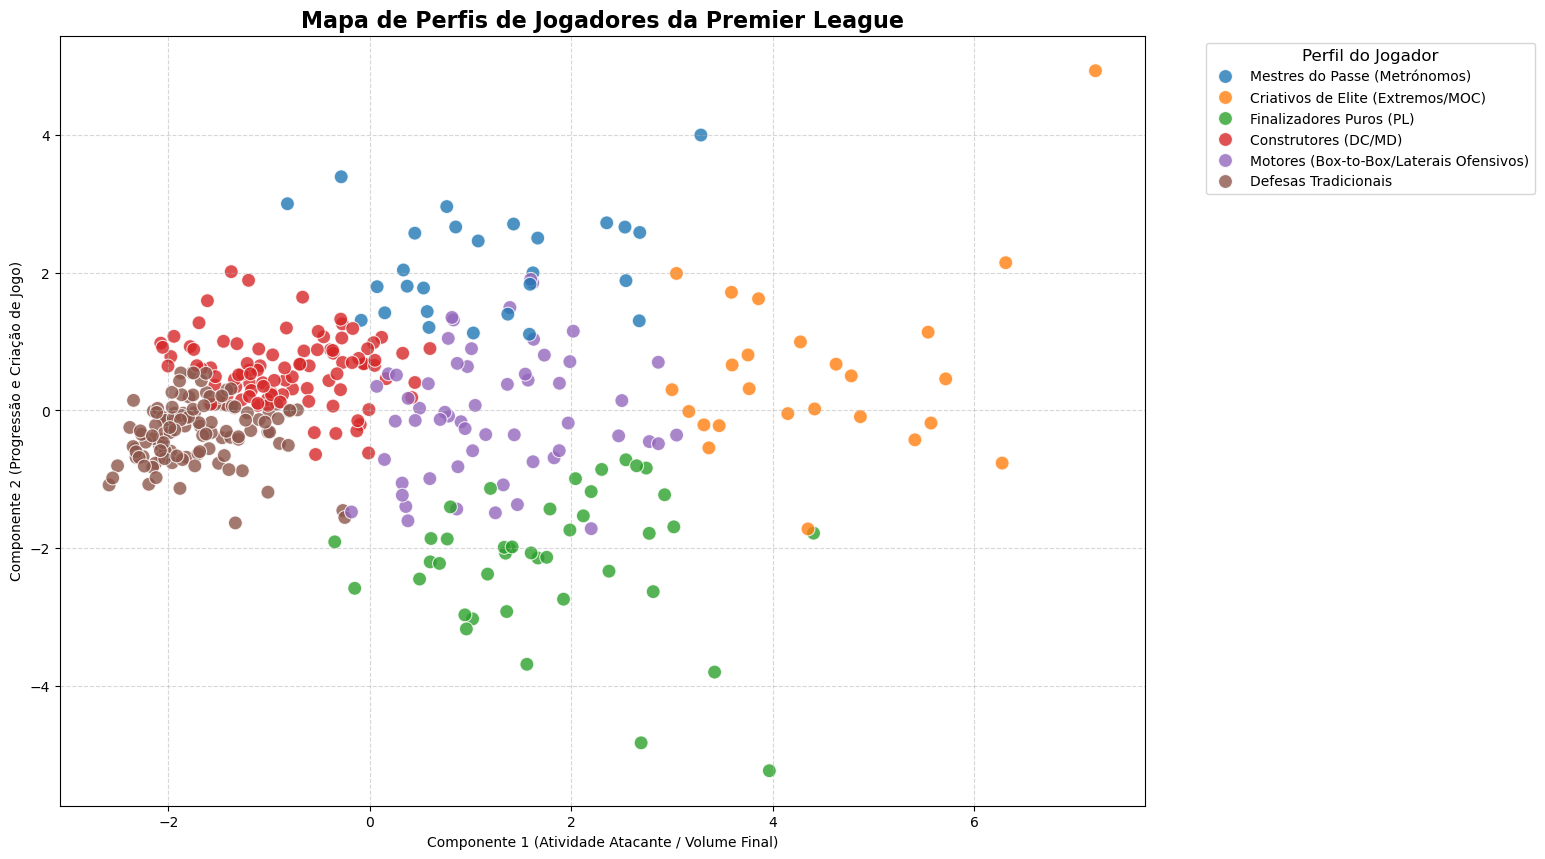

In [26]:
# Create a dictionary mapping the cluster numbers to our new profile names
nomes_clusters = {
    0: "Construtores (DC/MD)",
    1: "Criativos de Elite (Extremos/MOC)",
    2: "Motores (Box-to-Box/Laterais Ofensivos)",
    3: "Finalizadores Puros (PL)",
    4: "Defesas Tradicionais",
    5: "Mestres do Passe (Metrónomos)"
}

# Add a new column to the dataframe mapping the numbers to the names
df_filtered['Perfil_do_Jogador'] = df_filtered['Cluster'].map(nomes_clusters)

# Now, let's redraw our scatter plot using the new names!
plt.figure(figsize=(14, 10))

sns.scatterplot(
    x='PCA1', 
    y='PCA2', 
    hue='Perfil_do_Jogador', # <-- Usamos a nova coluna com os nomes!
    data=df_filtered, 
    palette='tab10',         # 'tab10' é excelente para distinguir muitas categorias
    s=100,             
    alpha=0.8          
)

plt.title('Mapa de Perfis de Jogadores da Premier League', fontsize=16, weight='bold')
plt.xlabel('Componente 1 (Atividade Atacante / Volume Final)')
plt.ylabel('Componente 2 (Progressão e Criação de Jogo)')
plt.legend(title='Perfil do Jogador', title_fontsize='12', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

# Podes também ver os jogadores de um grupo usando o novo nome:
# df_filtered[df_filtered['Perfil_do_Jogador'] == 'Finalizadores Puros (PL)'].head()


In [31]:
import plotly.express as px

# O Plotly Express faz a magia num único comando
fig = px.scatter(
    df_filtered, 
    x='PCA1', 
    y='PCA2', 
    color='Perfil_do_Jogador', # Vai usar as cores consoante a nossa nova coluna
    hover_name='Player',       # Título da caixinha que aparece ao passar o rato (Nome do Jogador)
    hover_data={               # O que queremos mostrar a mais na caixinha de informação
        'Team': True,
        'Pos': True,
        'PCA1': False,         # Esconder as coordenadas matemáticas porque não interessam muito ler
        'PCA2': False,
        'Gls_90': True,        # Mostrar os golos p/90 mins
        'xG_90': True,         # Mostrar o xG p/90 mins
        'PrgP_90': True        # Mostrar os Passes Progressivos
    },
    title="Mapa de Interativo de Jogadores da Premier League (Passa o rato!)",
    width=1000, 
    height=700
)

# Mostrar o gráfico interativo no Notebook
fig.show()


In [36]:
# 1. Qual o nome a pesquisar?
nome_pesquisa = "Bruno Fernandes"
# 2. Recriar sempre o mapa limpo
fig = px.scatter(
    df_filtered, 
    x='PCA1', 
    y='PCA2', 
    color='Perfil_do_Jogador',
    hover_name='Player',
    hover_data={'Team': True, 'Pos': True, 'PCA1': False, 'PCA2': False, 
                'Gls_90': True, 'xG_90': True, 'PrgP_90': True},
    title=f"Mapa de Estilos Interativo - À procura de: {nome_pesquisa}",
    width=1000, 
    height=700
)
# 3. Procurar o jogador no dataset
jogador_encontrado = df_filtered[df_filtered['Player'].str.contains(nome_pesquisa, case=False, na=False)]
# 4. Desenhar a estrela se ele existir
if not jogador_encontrado.empty:
    nome_real = jogador_encontrado['Player'].values[0]
    perfil = jogador_encontrado['Perfil_do_Jogador'].values[0]
    
    print(f"✅ SUCESSO: O {nome_real} é do tipo '{perfil}'")
    
    fig.add_scatter(
        x=jogador_encontrado['PCA1'], 
        y=jogador_encontrado['PCA2'], 
        mode='markers+text',
        marker=dict(color='red', size=20, symbol='star', line=dict(color='black', width=2)),
        text=jogador_encontrado['Player'],
        textfont=dict(size=14, color='red'),
        textposition='top center',
        name='Pesquisa'
    )
else:
    print(f"❌ ERRO: Não há ninguém com o nome '{nome_pesquisa}' no dataset!")
# Mostrar o gráfico final (Limpo + Apenas 1 Estrela)
fig.show()

✅ SUCESSO: O Bruno Fernandes é do tipo 'Mestres do Passe (Metrónomos)'
